## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## Loading Dataset

In [4]:
data = pd.read_csv('netflix_titles.csv')
print('Shape:', data.shape)
print('\nColumns:', data.columns.tolist())
data.head()

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Cleaning & Preprocessing

In [5]:
# Check nulls and duplicates
print('Null values:\n', data.isnull().sum())
print('\nDuplicates:', data.duplicated().sum())

Null values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicates: 0


In [6]:
# Drop null values — fix: use data not df
df = data.dropna()
print('Shape after dropping nulls:', df.shape)

Shape after dropping nulls: (5332, 12)


In [7]:
# Parse date_added into day, month, year
df = df.copy()
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')
df['day_added']   = df['date_added'].dt.day.astype('Int64')
df['month_added'] = df['date_added'].dt.month.astype('Int64')
df['year_added']  = df['date_added'].dt.year.astype('Int64')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,day_added,month_added,year_added
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",24,9,2021
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,24,9,2021
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,24,9,2021
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,23,9,2021
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,21,9,2021


## Data Visualization

1. Movie VS TV Shows Distribution

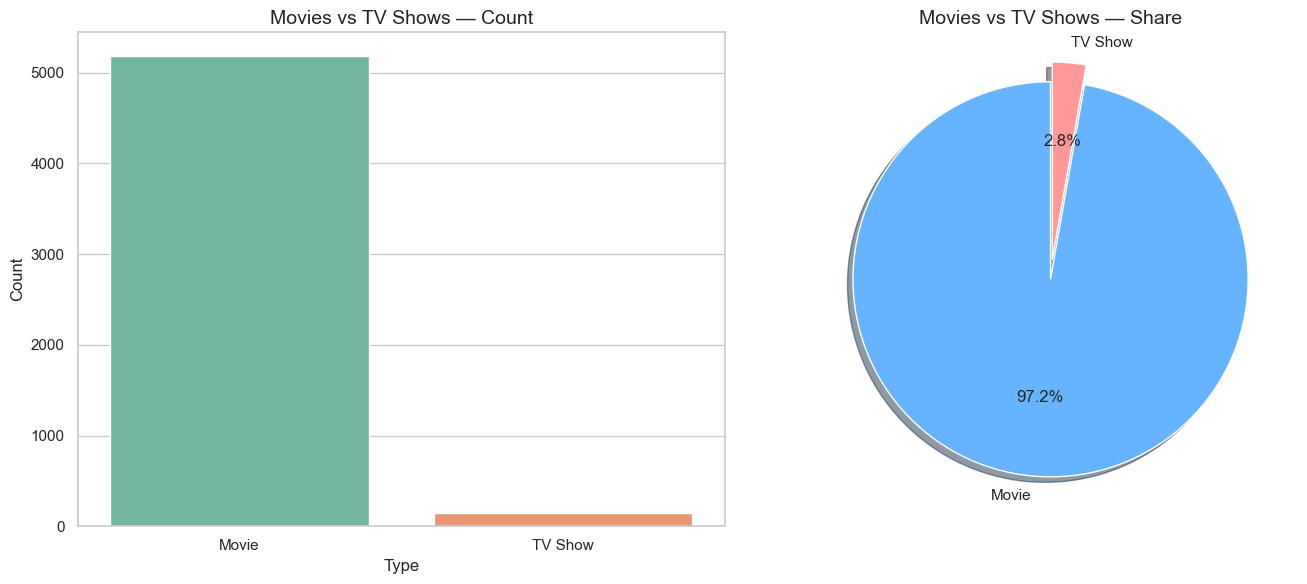

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Movies vs TV Shows — Count', fontsize=14)
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')

# Pie chart
size = df['type'].value_counts()
axes[1].pie(size, labels=size.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'],
            explode=[0, 0.1], shadow=True, startangle=90)
axes[1].set_title('Movies vs TV Shows — Share', fontsize=14)

plt.tight_layout()
plt.savefig('outputs/movies_vs_tvshows.png', bbox_inches='tight')
plt.show()

2. Rating Distribution

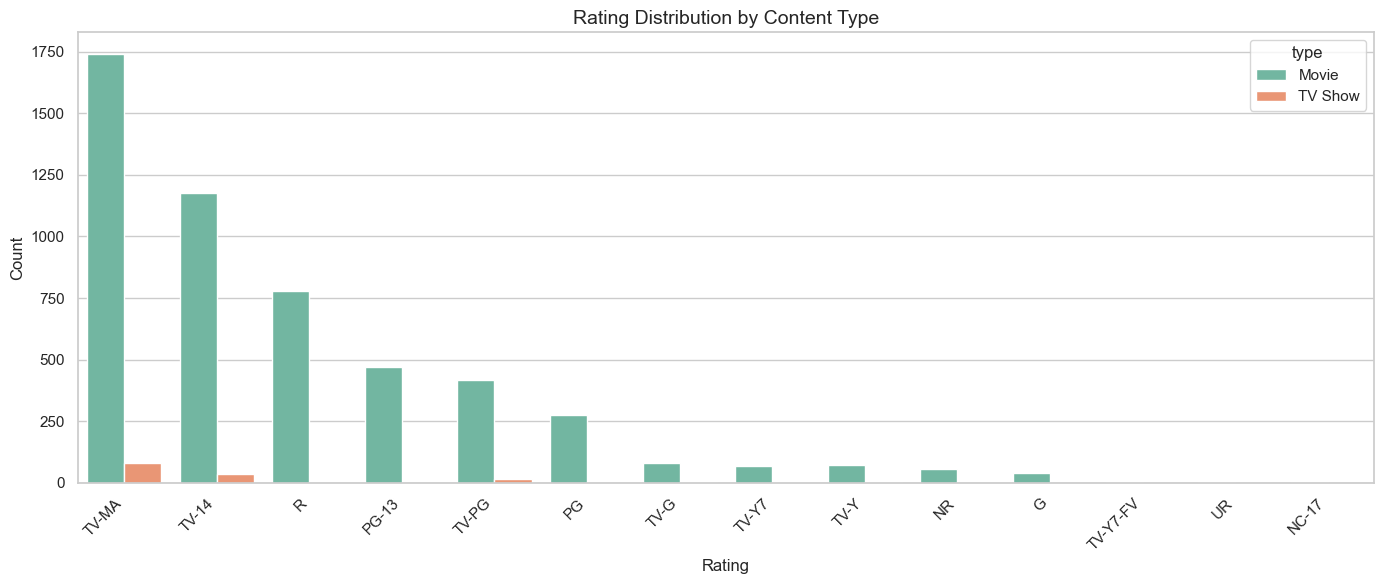

In [9]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='rating', hue='type', palette='Set2',
              order=df['rating'].value_counts().index)
plt.title('Rating Distribution by Content Type', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/rating_distribution.png', bbox_inches='tight')
plt.show()

3. Content Added Over the Years as Trend Analysis

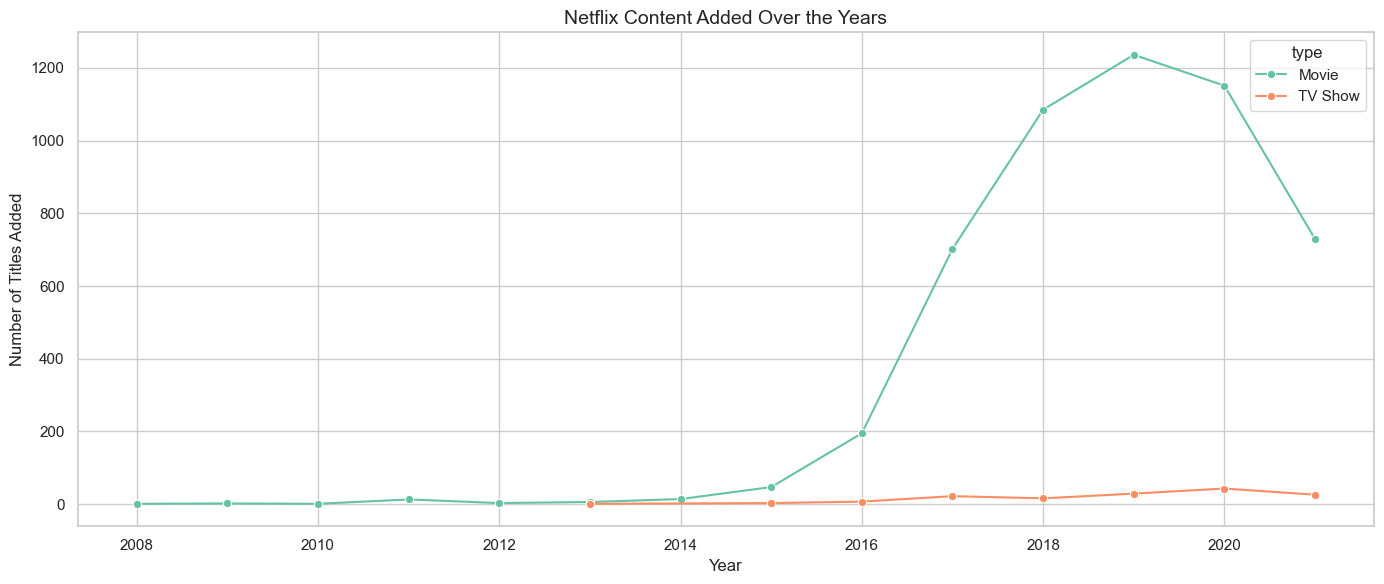

In [10]:
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')
yearly = yearly[yearly['year_added'].notna()]

plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly, x='year_added', y='count', hue='type', marker='o', palette='Set2')
plt.title('Netflix Content Added Over the Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.tight_layout()
plt.savefig('outputs/content_trend_over_years.png', bbox_inches='tight')
plt.show()

4. Top 10 Countries Producing Content

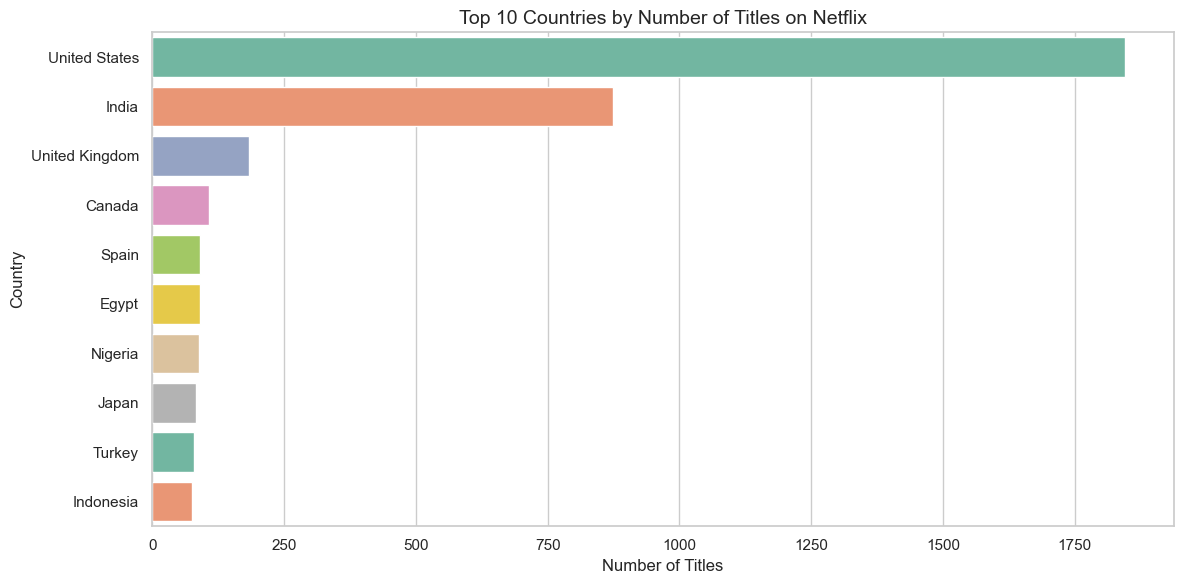

In [11]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='Set2', legend=False)
plt.title('Top 10 Countries by Number of Titles on Netflix', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('outputs/top_countries.png', bbox_inches='tight')
plt.show()

5. Top 10 Genres

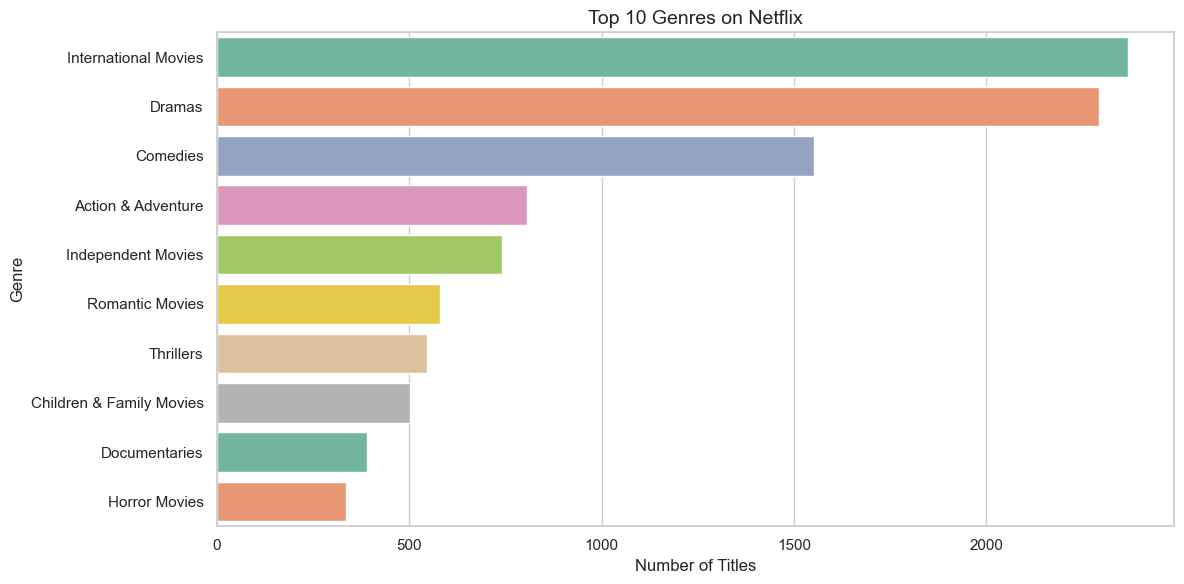

In [12]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='Set2', legend=False)
plt.title('Top 10 Genres on Netflix', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('outputs/top_genres.png', bbox_inches='tight')
plt.show()

## WordCloud

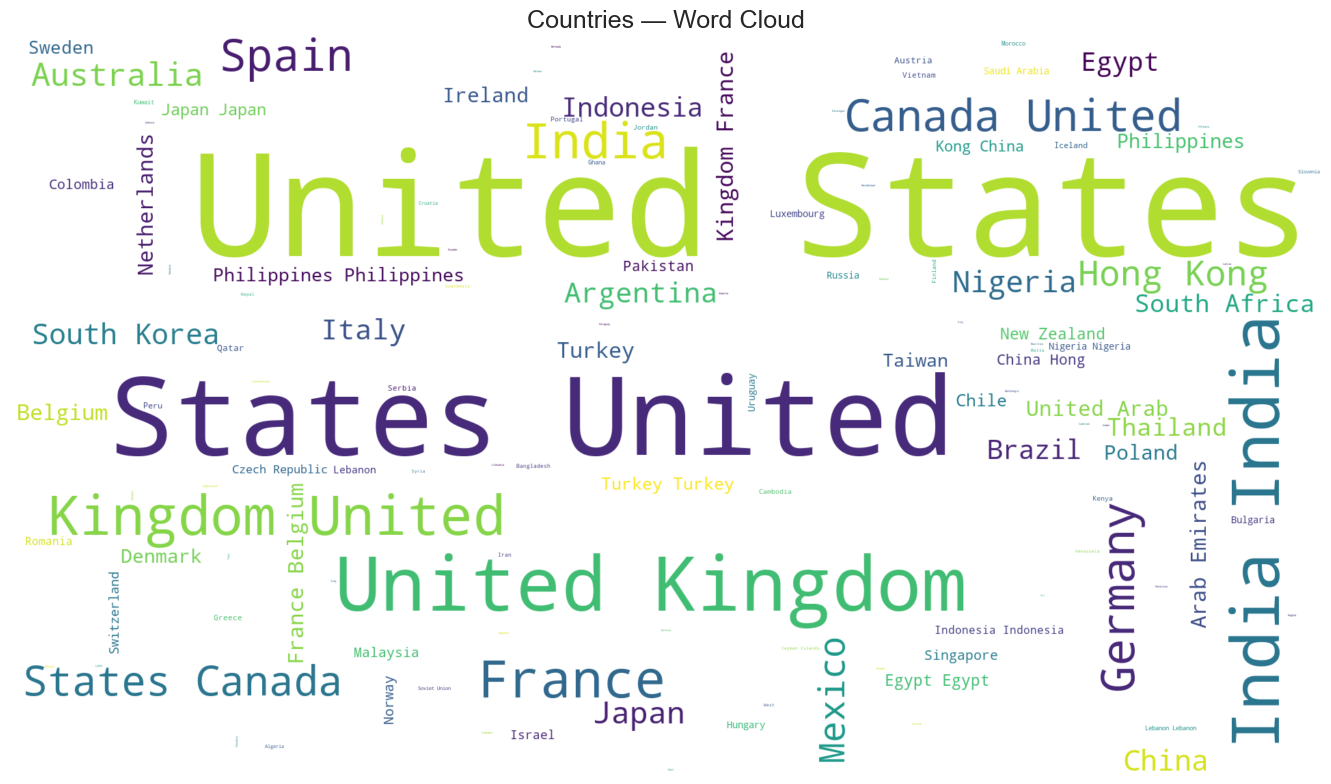

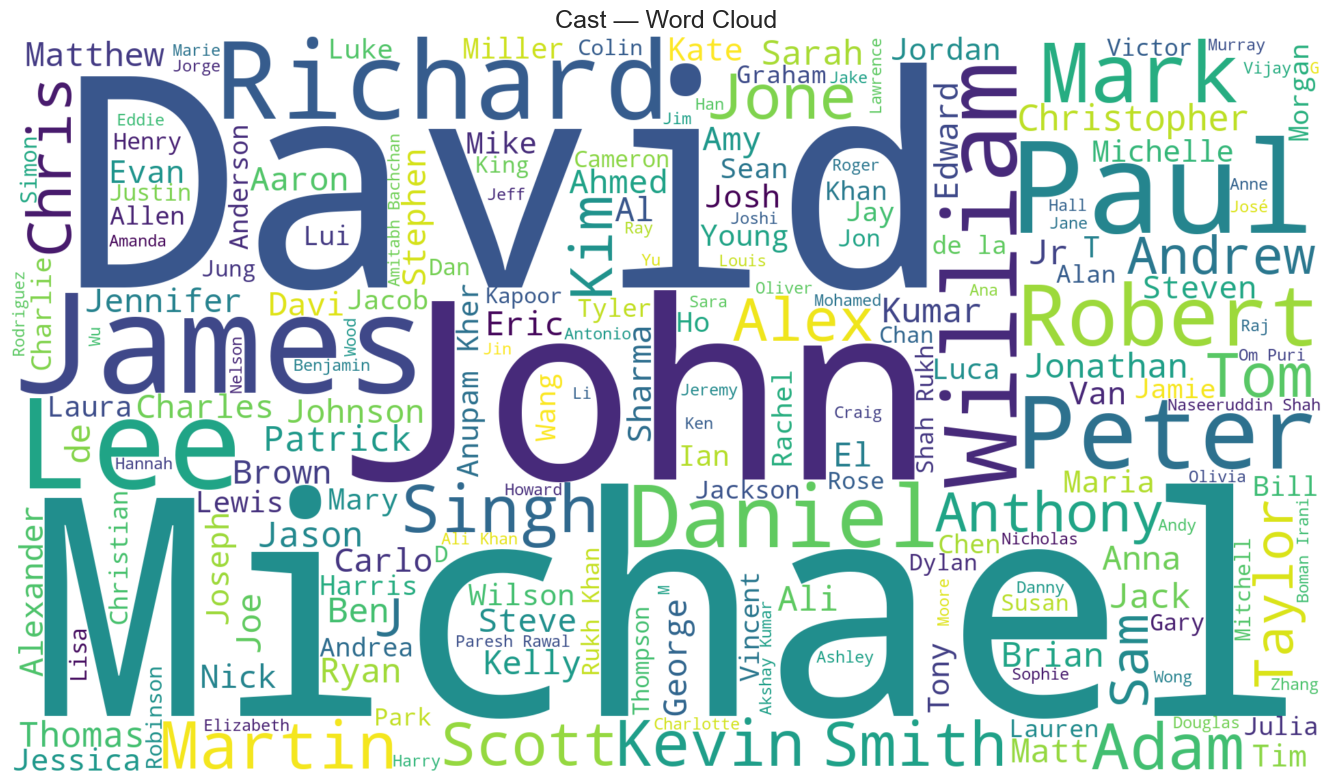

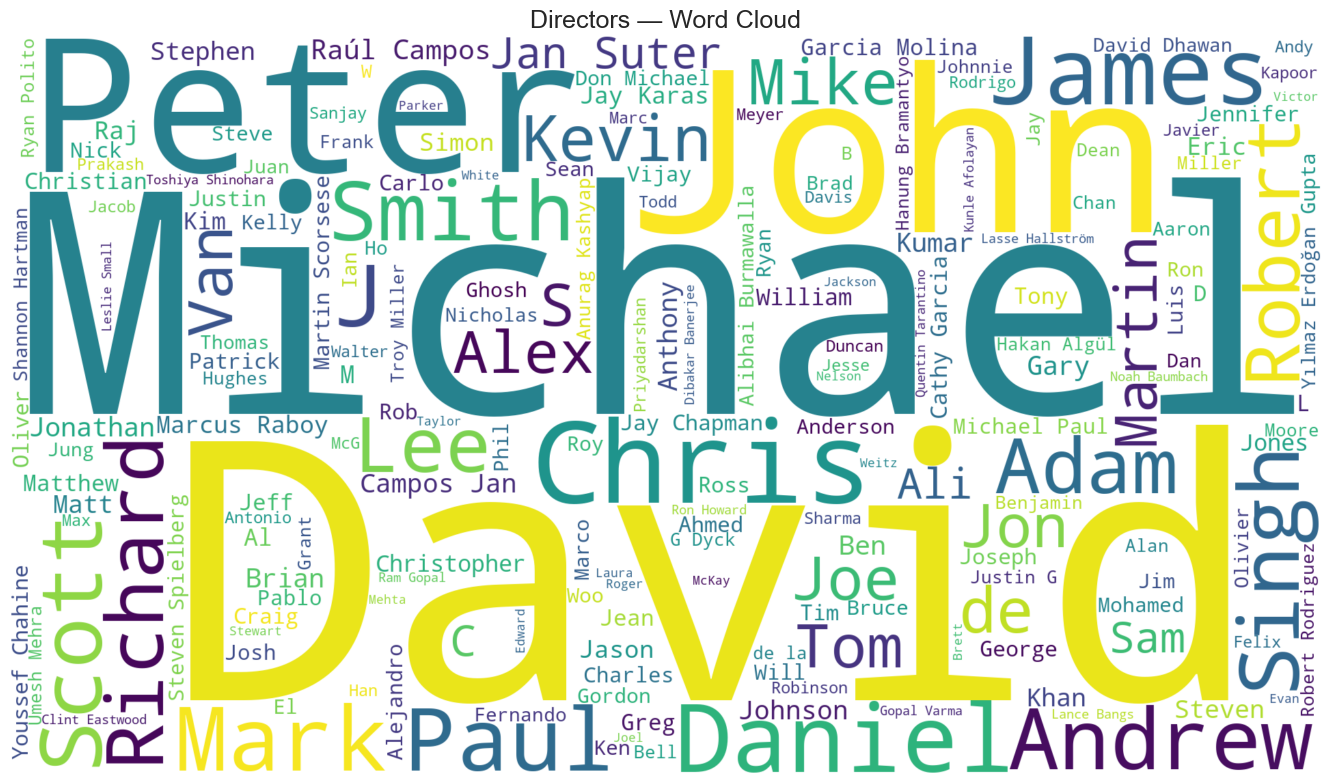

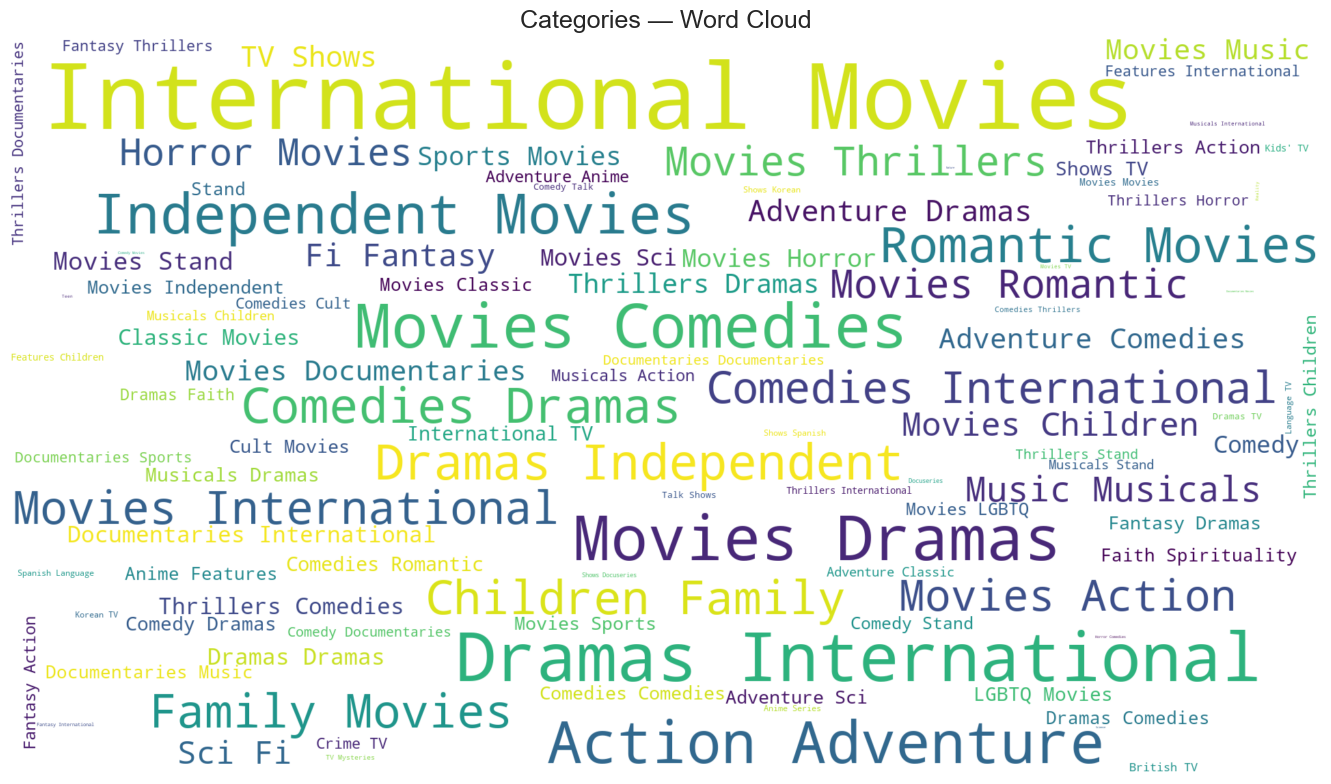

In [13]:
def generate_wordcloud(column, title, filename):
    text = ' '.join(df[column].dropna())
    wc = WordCloud(background_color='white', width=1920, height=1080).generate(text)
    plt.figure(figsize=(16, 8))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.savefig(f'outputs/{filename}', bbox_inches='tight')
    plt.show()

generate_wordcloud('country',   'Countries — Word Cloud',  'wordcloud_country.png')
generate_wordcloud('cast',      'Cast — Word Cloud',        'wordcloud_cast.png')
generate_wordcloud('director',  'Directors — Word Cloud',   'wordcloud_director.png')
generate_wordcloud('listed_in', 'Categories — Word Cloud',  'wordcloud_categories.png')

## Key Insights

In [14]:
print('=== KEY INSIGHTS ===')
print(f"1. Content Split: {df['type'].value_counts().to_dict()}")
print(f"2. Most Common Rating: {df['rating'].value_counts().idxmax()}")
print(f"3. Peak Content Year: {df['year_added'].value_counts().idxmax()}")
print(f"4. Top Country: {df['country'].value_counts().idxmax()}")
print(f"5. Top Genre: {genres.value_counts().idxmax()}")

=== KEY INSIGHTS ===
1. Content Split: {'Movie': 5185, 'TV Show': 147}
2. Most Common Rating: TV-MA
3. Peak Content Year: 2019
4. Top Country: United States
5. Top Genre: International Movies
